In [1]:
#installing necessary dependencies
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["torch", "torchvision", "numpy", "matplotlib", "pandas", "tqdm"]:
    try:
        __import__(pkg if pkg != "torchvision" else "torchvision")
    except ImportError:
        install(pkg)

print("All packages available.")

All packages available.


In [2]:
# Core Imports
import os, csv, time, math, copy, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
from tqdm.auto import tqdm


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False  # False = fast
    torch.backends.cudnn.benchmark     = True   # True = auto-tune CUDA kernels

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA L4


/home/links/ps758/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#CIFAR-10 / CIFAR-100 Dataloader

DATA_DIR = "./data"

# Means and stds for normalisation (CIFAR-10 / CIFAR-100)
CIFAR10_MEAN  = (0.4914, 0.4822, 0.4465)
CIFAR10_STD   = (0.2023, 0.1994, 0.2010)
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

def get_loaders(dataset="cifar10", batch_size=256, num_workers=0):
    """Return (train_loader, test_loader, num_classes)."""
    assert dataset in ("cifar10", "cifar100")
    mean = CIFAR10_MEAN  if dataset == "cifar10" else CIFAR100_MEAN
    std  = CIFAR10_STD   if dataset == "cifar10" else CIFAR100_STD
    num_classes = 10     if dataset == "cifar10" else 100
    cls = torchvision.datasets.CIFAR10 if dataset == "cifar10" else torchvision.datasets.CIFAR100

    train_tf = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ColorJitter(0.4, 0.4, 0.4, 0.1),   # extra augmentation
        T.ToTensor(),
        T.Normalize(mean, std),
    ])
    test_tf = T.Compose([
        T.ToTensor(),
        T.Normalize(mean, std),
    ])

    train_ds = cls(root=DATA_DIR, train=True,  download=True, transform=train_tf)
    test_ds  = cls(root=DATA_DIR, train=False, download=True, transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True,
                              drop_last=True, persistent_workers=(num_workers>0))
    test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader, num_classes

print("Dataloader function ready.")

Dataloader function ready.


In [4]:
# CELL 4 — CIFAR ResNet-34 (3x3 stem, no maxpool)
# ResNet-34 uses [3, 4, 6, 3] BasicBlocks vs [2, 2, 2, 2] in ResNet-18

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))


class CIFARResNet34(nn.Module):
    """
    ResNet-34 adapted for 32x32 CIFAR images.
    Block config: [3, 4, 6, 3]  (vs [2,2,2,2] for ResNet-18)
    Stem: 3x3 conv stride-1, no MaxPool.
    ~21.3 M parameters.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.layer1 = self._make_layer(64,  64,  num_blocks=3, stride=1)
        self.layer2 = self._make_layer(64,  128, num_blocks=4, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=6, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=3, stride=2)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(512, num_classes)
        self._init_weights()

    def _make_layer(self, in_ch, out_ch, num_blocks, stride):
        layers = [BasicBlock(in_ch, out_ch, stride)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


def build_model(num_classes=10):
    return CIFARResNet34(num_classes=num_classes).to(DEVICE)


# Quick sanity check
_m = build_model(10)
_x = torch.randn(4, 3, 32, 32).to(DEVICE)
print("Output shape:", _m(_x).shape)
total = sum(p.numel() for p in _m.parameters())
print(f"Model: CIFARResNet-34")
print(f"Total parameters: {total:,} (~{total/1e6:.2f}M)")
del _m, _x

Output shape: torch.Size([4, 10])
Model: CIFARResNet-34
Total parameters: 21,282,122 (~21.28M)


In [5]:
# CELL 5 — Optimizer Implementations

import torch
from torch.optim import Optimizer
# Helper: Newton-Schulz orthogonalisation (5 iterations, fast) which is used by Muon to orthogonalise the gradient matrix

def zeropower_via_newtonschulz5(G, steps=5):
    """Compute G @ (G^T G)^{-1/2}  via 5 Newton-Schulz iterations."""
    assert G.ndim >= 2
    a, b, c = (3.4445, -4.7750, 2.0315)   # coefficients from the Muon paper
    X = G.bfloat16() if G.is_cuda else G.float()
    if X.size(0) > X.size(1):
        X = X.T
    X = X / (X.norm() + 1e-7)
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * (A @ A)
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X.to(G.dtype)
    
# Cautious AdamW

class CautiousAdamW(Optimizer):
    """AdamW with the cautious update mask from Li & Liang (2024)."""
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999),
                 eps=1e-8, weight_decay=0.01):
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure is not None else None
        for group in self.param_groups:
            lr  = group['lr']
            b1, b2 = group['betas']
            eps = group['eps']
            wd  = group['weight_decay']
            for p in group['params']:
                if p.grad is None:
                    continue
                g = p.grad
                state = self.state[p]
                if len(state) == 0:
                    state['step'] = 0
                    state['m']    = torch.zeros_like(p)
                    state['v']    = torch.zeros_like(p)
                m, v = state['m'], state['v']
                state['step'] += 1
                t = state['step']
                m.mul_(b1).add_(g, alpha=1 - b1)
                v.mul_(b2).addcmul_(g, g, value=1 - b2)
                m_hat = m / (1 - b1 ** t)
                v_hat = v / (1 - b2 ** t)
                update = m_hat / (v_hat.sqrt() + eps)
                # Cautious mask
                mask = (m_hat * g > 0).float()
                mask = mask * (mask.numel() / (mask.sum() + 1))  # normalise
                p.mul_(1 - lr * wd)
                p.add_(update * mask, alpha=-lr)
        return loss



# Muon and Cautious Muon
class Muon(Optimizer):
    """Muon optimiser
    Setting cautious=True to get C-Muon.
    """
    def __init__(self, muon_params, lr=0.02, momentum=0.95,
                 adamw_params=None, adamw_lr=3e-4,
                 adamw_betas=(0.95, 0.999), adamw_wd=0.01,
                 ns_steps=5, cautious=False): 
        self._adamw_params = list(adamw_params) if adamw_params is not None else []
        self.ns_steps  = ns_steps
        self.cautious  = cautious
        self._adamw_state = {}
        self._adamw_cfg   = dict(lr=adamw_lr, betas=adamw_betas, wd=adamw_wd)
        defaults = dict(lr=lr, momentum=momentum)
        super().__init__(muon_params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure is not None else None

        # Muon update for matrix-like params
        for group in self.param_groups:
            lr  = group['lr']
            mu  = group['momentum']
            for p in group['params']:
                if p.grad is None:
                    continue
                g = p.grad
                state = self.state[p]
                if len(state) == 0:
                    state['buf'] = torch.zeros_like(g)
                buf = state['buf']
                # Nesterov momentum
                buf.mul_(mu).add_(g)
                g_nes = g.add(buf, alpha=mu)   # g + mu*buf
                # Reshape to 2-D for orthogonalisation
                orig_shape = g_nes.shape
                if g_nes.ndim > 2:
                    g2d = g_nes.view(g_nes.size(0), -1)
                elif g_nes.ndim == 2:
                    g2d = g_nes
                else:
                    # 1-D or scalar: skip ortho, use plain scaled update
                    p.add_(g_nes, alpha=-lr)
                    continue
                ortho = zeropower_via_newtonschulz5(g2d, steps=self.ns_steps)
                update = ortho.view(orig_shape) * max(1, orig_shape[0] / orig_shape[-1]) ** 0.5
                if self.cautious:
                    mask = (update * g > 0).float()
                    mask = mask * (mask.numel() / (mask.sum() + 1))
                    p.add_(update * mask, alpha=-lr)
                else:
                    p.add_(update, alpha=-lr)

        # AdamW fallback for non-matrix params 
        lr2  = self._adamw_cfg['lr']
        b1, b2 = self._adamw_cfg['betas']
        wd   = self._adamw_cfg['wd']
        eps  = 1e-8
        for p in self._adamw_params:
            if p.grad is None:
                continue
            g = p.grad
            sid = id(p)
            if sid not in self._adamw_state:
                self._adamw_state[sid] = {'step':0,
                                           'm': torch.zeros_like(p),
                                           'v': torch.zeros_like(p)}
            s = self._adamw_state[sid]
            s['step'] += 1; t = s['step']
            s['m'].mul_(b1).add_(g, alpha=1-b1)
            s['v'].mul_(b2).addcmul_(g, g, value=1-b2)
            m_hat = s['m'] / (1 - b1**t)
            v_hat = s['v'] / (1 - b2**t)
            update = m_hat / (v_hat.sqrt() + eps)
            p.mul_(1 - lr2 * wd)
            p.add_(update, alpha=-lr2)
        return loss



# Factory: build_optimizer(model, name, ...)
def is_muon_param(name, p):
    """Return True if a parameter should use Muon (matrix-like, hidden layer)."""
    if p.ndim < 2:
        return False
    if 'fc' in name or 'stem' in name:
        return False
    return True


def build_optimizer(model, name,
                    sgd_lr=0.1, sgd_mom=0.9, sgd_wd=5e-4,
                    adam_lr=1e-3, adam_wd=0.01,
                    muon_lr=0.02, muon_mom=0.95,
                    adamw_lr=3e-4):
    name = name.lower()
    if name == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=sgd_lr,
                               momentum=sgd_mom, weight_decay=sgd_wd,
                               nesterov=True)
    elif name == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=adam_lr,
                                 weight_decay=adam_wd)
    elif name == 'c_adamw':
        return CautiousAdamW(model.parameters(), lr=adam_lr,
                             weight_decay=adam_wd)
    elif name in ('muon', 'c_muon'):
        muon_p, other_p = [], []
        for n, p in model.named_parameters():
            if is_muon_param(n, p):
                muon_p.append(p)
            else:
                other_p.append(p)
        print(f"  Muon params: {len(muon_p)}  |  AdamW-fallback params: {len(other_p)}")
        return Muon(muon_params=muon_p, lr=muon_lr, momentum=muon_mom,
                    adamw_params=other_p, adamw_lr=adamw_lr,
                    cautious=(name == 'c_muon'))
    else:
        raise ValueError(f"Unknown optimizer: {name}")

print("Optimizer classes ready: SGD | AdamW | C-AdamW | Muon | C-Muon")

Optimizer classes ready: SGD | AdamW | C-AdamW | Muon | C-Muon


In [6]:
#LR Scheduler + Evaluation helper
def get_lr(step, total_steps, base_lr, warmup_steps=1000, min_lr_frac=0.1):
    if step < warmup_steps:
        return base_lr * (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    cosine   = 0.5 * (1.0 + math.cos(math.pi * progress))
    return base_lr * (min_lr_frac + (1 - min_lr_frac) * cosine)


def set_lr(optimizer, lr):
    for g in optimizer.param_groups:
        g['lr'] = lr


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_loss += criterion(logits, y).item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += x.size(0)
    model.train()
    return total_loss / total, 100.0 * correct / total

print("Scheduler and evaluation helpers ready.")

Scheduler and evaluation helpers ready.


In [7]:
# CELL 7 — Main Training Loop (100 000 steps)
def train_one_optimizer(
        opt_name,
        dataset      = "cifar10",
        max_steps    = 100_000,
        batch_size   = 256,
        eval_every   = 1_000,
        base_lr      = None,       # auto if None
        warmup_steps = 1_000,
        out_dir      = "runs",
        seed         = 42,
):
    set_seed(seed)
    os.makedirs(out_dir, exist_ok=True)

    # ---- default LRs per optimizer ----
    LR_DEFAULTS = {
        'sgd':     0.1,
        'adamw':   1e-3,
        'c_adamw': 1e-3,
        'muon':    0.02,
        'c_muon':  0.02,
    }
    if base_lr is None:
        base_lr = LR_DEFAULTS[opt_name.lower()]

    # ---- data ----
    train_loader, test_loader, num_classes = get_loaders(dataset, batch_size)
    train_iter = iter(train_loader)

    # ---- model & optimizer ----
    model     = build_model(num_classes=num_classes)
    optimizer = build_optimizer(model, opt_name,
                                sgd_lr=base_lr, adam_lr=base_lr,
                                muon_lr=base_lr)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # ---- logging ----
    log_path = os.path.join(out_dir, f"{opt_name}_{dataset}.csv")
    records  = []
    fieldnames = ['step','lr','train_loss','train_acc','val_loss','val_acc','elapsed_s']
    csv_file = open(log_path, 'w', newline='')
    writer   = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()

    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    t0 = time.time()

    pbar = tqdm(range(1, max_steps + 1),
                desc=f"{opt_name.upper():8s} | {dataset}",
                dynamic_ncols=True)

    for step in pbar:
        # ---- LR schedule ----
        lr = get_lr(step - 1, max_steps, base_lr, warmup_steps)
        set_lr(optimizer, lr)

        # ---- get next batch (cycle the loader) ----
        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x, y = next(train_iter)

        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

        # ---- forward / backward ----
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # ---- running train stats ----
        with torch.no_grad():
            running_loss    += loss.item() * x.size(0)
            running_correct += (logits.argmax(1) == y).sum().item()
            running_total   += x.size(0)

        # ---- periodic evaluation ----
        if step % eval_every == 0 or step == max_steps:
            train_loss = running_loss  / running_total
            train_acc  = 100.0 * running_correct / running_total
            val_loss, val_acc = evaluate(model, test_loader)
            elapsed = time.time() - t0

            row = dict(step=step, lr=round(lr,8),
                       train_loss=round(train_loss,5),
                       train_acc=round(train_acc,3),
                       val_loss=round(val_loss,5),
                       val_acc=round(val_acc,3),
                       elapsed_s=round(elapsed,1))
            records.append(row)
            writer.writerow(row)
            csv_file.flush()

            pbar.set_postfix(
                tr_loss=f"{train_loss:.4f}",
                tr_acc=f"{train_acc:.1f}%",
                val_acc=f"{val_acc:.1f}%"
            )
            running_loss = running_correct = running_total = 0

    csv_file.close()

    # save final checkpoint 
    ckpt_path = os.path.join(out_dir, f"{opt_name}_{dataset}_final.pt")
    torch.save({'step': max_steps,
                'model_state': model.state_dict(),
                'val_acc':     records[-1]['val_acc']}, ckpt_path)

    print(f"\n[{opt_name}] Final val acc: {records[-1]['val_acc']:.2f}%  "
          f"| saved to {log_path}")
    return records

print("train_one_optimizer() ready.")

train_one_optimizer() ready.


In [8]:
# CELL 8 — Multi-Seed Benchmark (ResNet-34, 3 seeds x 5 optimizers)
# Seeds: 42, 123, 7  |  Optimizers: SGD, AdamW, C-AdamW, Muon, C-Muon

DATASET    = "cifar10"
MAX_STEPS  = 100_000
BATCH_SIZE = 256
EVAL_EVERY = 1_000
OUT_DIR    = "runs_v2"
SEEDS      = [42, 123, 7]          # 3 independent runs
OPTIMIZERS = ["sgd", "adamw", "c_adamw", "muon", "c_muon"]
# ----------------

ALL_RESULTS = {}   # (opt, seed) -> list of record dicts

for seed in SEEDS:
    seed_dir = os.path.join(OUT_DIR, f"seed_{seed}")
    os.makedirs(seed_dir, exist_ok=True)
    for opt in OPTIMIZERS:
        csv_path=os.path.join(seed_dir, f"{opt}_{DATASET}.csv")
        if os.path.exists(csv_path):
            print(f"[skip] {opt} seed {seed} already complete -> {csv_path}")
            df_done = pd.read_csv(csv_path)
            ALL_RESULTS[(opt, seed)] = df_done.to_dict("records")
            continue
        print(f"\n{'='*60}")
        print(f"  Optimizer: {opt.upper()}  |  Seed: {seed}")
        print(f"{'='*60}")
        records = train_one_optimizer(
            opt_name   = opt,
            dataset    = DATASET,
            max_steps  = MAX_STEPS,
            batch_size = BATCH_SIZE,
            eval_every = EVAL_EVERY,
            out_dir    = seed_dir,
            seed       = seed,
        )
        ALL_RESULTS[(opt, seed)] = records

print("\n" + "="*60)
print("MULTI-SEED BENCHMARK COMPLETE")
print(f"{'Optimizer':<14} {'Seed':>6} {'Best Val Acc':>13} {'Final Val Acc':>14}")
print("-"*50)
for (opt, seed), recs in ALL_RESULTS.items():
    val_accs = [r['val_acc'] for r in recs]
    print(f"{opt:<14} {seed:>6} {max(val_accs):>12.2f}%  {val_accs[-1]:>13.2f}%")
print("="*60)

[skip] sgd seed 42 already complete -> runs_v2/seed_42/sgd_cifar10.csv
[skip] adamw seed 42 already complete -> runs_v2/seed_42/adamw_cifar10.csv
[skip] c_adamw seed 42 already complete -> runs_v2/seed_42/c_adamw_cifar10.csv
[skip] muon seed 42 already complete -> runs_v2/seed_42/muon_cifar10.csv
[skip] c_muon seed 42 already complete -> runs_v2/seed_42/c_muon_cifar10.csv
[skip] sgd seed 123 already complete -> runs_v2/seed_123/sgd_cifar10.csv
[skip] adamw seed 123 already complete -> runs_v2/seed_123/adamw_cifar10.csv
[skip] c_adamw seed 123 already complete -> runs_v2/seed_123/c_adamw_cifar10.csv
[skip] muon seed 123 already complete -> runs_v2/seed_123/muon_cifar10.csv
[skip] c_muon seed 123 already complete -> runs_v2/seed_123/c_muon_cifar10.csv
[skip] sgd seed 7 already complete -> runs_v2/seed_7/sgd_cifar10.csv
[skip] adamw seed 7 already complete -> runs_v2/seed_7/adamw_cifar10.csv
[skip] c_adamw seed 7 already complete -> runs_v2/seed_7/c_adamw_cifar10.csv
[skip] muon seed 7 al

/home/links/ps758/.local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


  Muon params: 35  |  AdamW-fallback params: 75


C_MUON   | cifar10: 100%|█████| 100000/100000 [13:24:06<00:00,  2.07it/s, tr_acc=100.0%, tr_loss=0.5015, val_acc=94.4%]


[c_muon] Final val acc: 94.36%  | saved to runs_v2/seed_7/c_muon_cifar10.csv

MULTI-SEED BENCHMARK COMPLETE
Optimizer        Seed  Best Val Acc  Final Val Acc
--------------------------------------------------
sgd                42        93.96%          93.86%
adamw              42        94.27%          94.03%
c_adamw            42        94.33%          94.04%
muon               42        94.73%          94.69%
c_muon             42        94.81%          94.21%
sgd               123        94.17%          93.41%
adamw             123        94.24%          94.04%
c_adamw           123        94.10%          93.98%
muon              123        94.75%          94.66%
c_muon            123        94.87%          94.43%
sgd                 7        93.65%          93.65%
adamw               7        94.44%          94.00%
c_adamw             7        94.20%          93.98%
muon                7        94.64%          94.56%
c_muon              7        94.55%          94.36%


In [1]:

#  Multi-Seed Analysis: Mean ± Std across 3 seeds

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

OUT_DIR_V2 = "runs_v2"
DATASET    = "cifar10"
SEEDS      = [42, 123, 7]
OPT_ORDER  = ["sgd", "adamw", "c_adamw", "muon", "c_muon"]
LABELS = {
    "sgd"    : "SGD (momentum)",
    "adamw"  : "AdamW",
    "c_adamw": "Cautious AdamW",
    "muon"   : "Muon",
    "c_muon" : "Cautious Muon",
}
COLORS = {
    "sgd"    : "#4e79a7",
    "adamw"  : "#f28e2b",
    "c_adamw": "#e15759",
    "muon"   : "#76b7b2",
    "c_muon" : "#59a14f",
}
LINESTYLES = {"sgd":"-", "adamw":"-", "c_adamw":"--", "muon":"-", "c_muon":"--"}

# ── Load all seed CSVs ──────────────────────────────────
# seed_dfs[opt] = list of DataFrames, one per seed
seed_dfs = {opt: [] for opt in OPT_ORDER}
for seed in SEEDS:
    for opt in OPT_ORDER:
        path = os.path.join(OUT_DIR_V2, f"seed_{seed}", f"{opt}_{DATASET}.csv")
        if os.path.exists(path):
            seed_dfs[opt].append(pd.read_csv(path))
        else:
            print(f"  [WARN] missing: {path}")

avail = {o: seed_dfs[o] for o in OPT_ORDER if seed_dfs[o]}
print(f"Loaded data for: {list(avail.keys())}")
for opt, dfs in avail.items():
    print(f"  {LABELS[opt]}: {len(dfs)} seed(s)")

# ── Compute mean ± std over seeds at each eval step ──────────
def aggregate(dfs, col):
    """Stack column across seed DataFrames and return (steps, mean, std)."""
    arrays = np.stack([df[col].values for df in dfs], axis=0)  # [seeds, steps]
    return dfs[0]['step'].values, arrays.mean(0), arrays.std(0)

# ── Summary table ──────────────────────────────────────

print("  MULTI-SEED RESULTS — CIFAR-10 | CIFARResNet-34 | 100k steps")

print(f"{'Optimizer':<18} {'Best Acc (mean±std)':>22} {'Final Acc (mean±std)':>22}")


rows = []
for opt in OPT_ORDER:
    if opt not in avail:
        continue
    dfs = avail[opt]
    best_per_seed  = [df['val_acc'].max()   for df in dfs]
    final_per_seed = [df['val_acc'].iloc[-1] for df in dfs]
    bm, bs = np.mean(best_per_seed),  np.std(best_per_seed)
    fm, fs = np.mean(final_per_seed), np.std(final_per_seed)
    label = LABELS[opt]
    print(f"{label:<18}  {bm:>6.2f}% ± {bs:.2f}%       {fm:>6.2f}% ± {fs:.2f}%")
    rows.append(dict(Optimizer=label,
                     Best_mean=round(bm,3), Best_std=round(bs,3),
                     Final_mean=round(fm,3), Final_std=round(fs,3),
                     N_seeds=len(dfs)))
print("="*72)

summary_df = pd.DataFrame(rows)
summary_path = os.path.join(OUT_DIR_V2, "summary_multiseed.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\nSummary saved to {summary_path}")

# ── 4-panel figure with shaded std bands ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Optimizer Comparison — CIFAR-10 | CIFARResNet-34 | 3 Seeds (mean ± std)",
             fontsize=13, fontweight='bold', y=1.01)
ax_vacc, ax_vloss, ax_tacc, ax_tloss = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

panels = [
    (ax_vacc,  'val_acc',   "Validation Accuracy",          "Accuracy (%)"),
    (ax_vloss, 'val_loss',  "Validation Loss",              "Cross-Entropy Loss"),
    (ax_tacc,  'train_acc', "Train Accuracy",               "Accuracy (%)"),
    (ax_tloss, 'train_loss',"Train Loss (label-smoothed)",  "Loss"),
]

for ax, col, title, ylabel in panels:
    for opt in OPT_ORDER:
        if opt not in avail or not avail[opt]:
            continue
        steps, mean, std = aggregate(avail[opt], col)
        c  = COLORS[opt]
        ls = LINESTYLES[opt]
        ax.plot(steps, mean, color=c, linestyle=ls, linewidth=1.8,
                label=LABELS[opt], alpha=0.9)
        ax.fill_between(steps, mean-std, mean+std, color=c, alpha=0.15)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Training Step", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{int(x/1000)}k" if x >= 1000 else str(int(x))))
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8, loc='lower right' if 'Acc' in title else 'upper right')

plt.tight_layout()
fig_path = os.path.join(OUT_DIR_V2, "benchmark_resnet34_multiseed.png")
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n4-panel figure saved to {fig_path}")
print("Cell 9 done.")

  [WARN] missing: runs_v2/seed_42/sgd_cifar10.csv
  [WARN] missing: runs_v2/seed_42/adamw_cifar10.csv
  [WARN] missing: runs_v2/seed_42/c_adamw_cifar10.csv
  [WARN] missing: runs_v2/seed_42/muon_cifar10.csv
  [WARN] missing: runs_v2/seed_42/c_muon_cifar10.csv
  [WARN] missing: runs_v2/seed_123/sgd_cifar10.csv
  [WARN] missing: runs_v2/seed_123/adamw_cifar10.csv
  [WARN] missing: runs_v2/seed_123/c_adamw_cifar10.csv
  [WARN] missing: runs_v2/seed_123/muon_cifar10.csv
  [WARN] missing: runs_v2/seed_123/c_muon_cifar10.csv
  [WARN] missing: runs_v2/seed_7/sgd_cifar10.csv
  [WARN] missing: runs_v2/seed_7/adamw_cifar10.csv
  [WARN] missing: runs_v2/seed_7/c_adamw_cifar10.csv
  [WARN] missing: runs_v2/seed_7/muon_cifar10.csv
  [WARN] missing: runs_v2/seed_7/c_muon_cifar10.csv
Loaded data for: []
  MULTI-SEED RESULTS — CIFAR-10 | CIFARResNet-34 | 100k steps
Optimizer             Best Acc (mean±std)   Final Acc (mean±std)


OSError: Cannot save file into a non-existent directory: 'runs_v2'

  PER-SEED RESULTS — Best Val Acc (%) — CIFARResNet-34
Optimizer       Seed  42  Seed 123  Seed   7   Mean±Std
------------------------------------------------------------------------
SGD                93.96%     94.17%     93.65%   93.93±0.21%
AdamW              94.27%     94.24%     94.44%   94.32±0.09%
C-AdamW            94.33%     94.10%     94.20%   94.21±0.09%
Muon               94.73%     94.75%     94.64%   94.71±0.05%
C-Muon             94.81%     94.87%     94.55%   94.74±0.14%


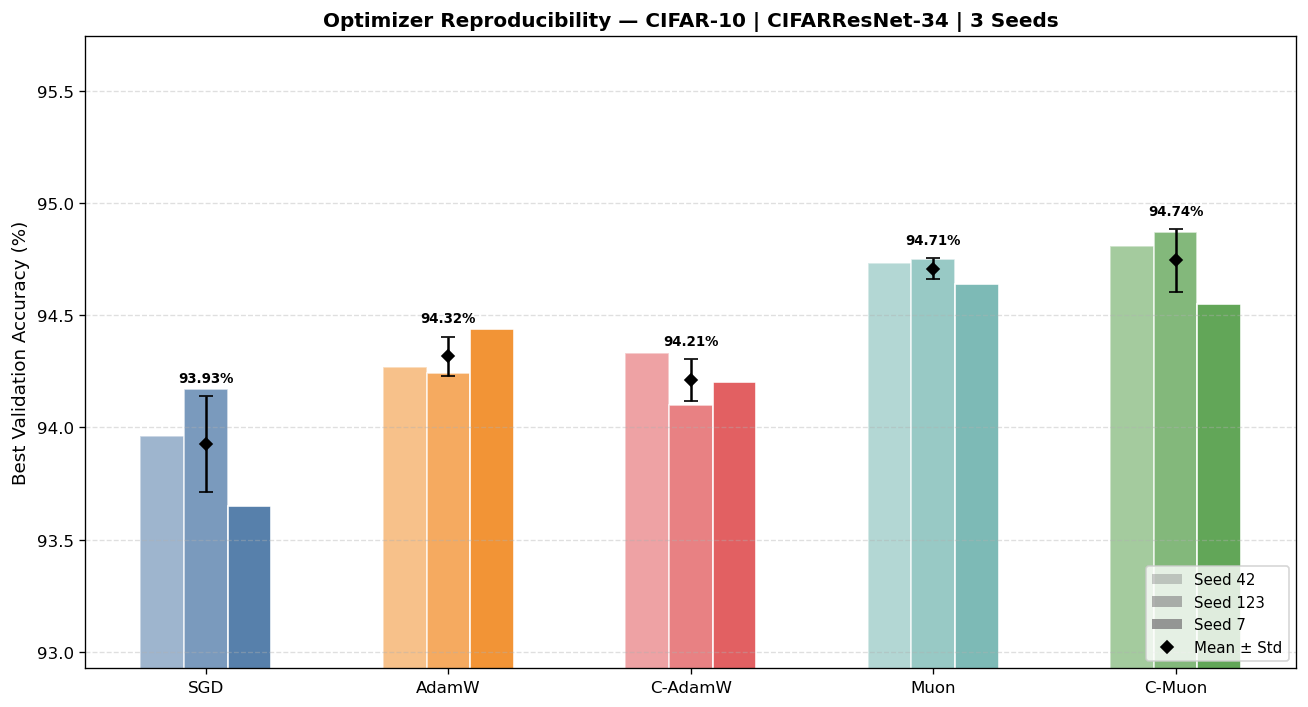


Bar chart saved to runs_v2/benchmark_resnet34_bar.png

All analysis complete.


In [10]:
# ============================================================
# CELL 10 — Grouped Bar Chart with Error Bars (mean ± std)
#           + Per-seed table for reproducibility check
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR_V2 = "runs_v2"
DATASET    = "cifar10"
SEEDS      = [42, 123, 7]
OPT_ORDER  = ["sgd", "adamw", "c_adamw", "muon", "c_muon"]
LABELS = {
    "sgd"    : "SGD",
    "adamw"  : "AdamW",
    "c_adamw": "C-AdamW",
    "muon"   : "Muon",
    "c_muon" : "C-Muon",
}
COLORS = {
    "sgd"    : "#4e79a7",
    "adamw"  : "#f28e2b",
    "c_adamw": "#e15759",
    "muon"   : "#76b7b2",
    "c_muon" : "#59a14f",
}

# ── Reload CSVs (safe to run standalone) ──────────────────
seed_dfs = {opt: [] for opt in OPT_ORDER}
for seed in SEEDS:
    for opt in OPT_ORDER:
        path = os.path.join(OUT_DIR_V2, f"seed_{seed}", f"{opt}_{DATASET}.csv")
        if os.path.exists(path):
            seed_dfs[opt].append((seed, pd.read_csv(path)))

# ── Per-seed reproducibility table ────────────────────────

print("  PER-SEED RESULTS — Best Val Acc (%) — CIFARResNet-34")
hdr = f"{'Optimizer':<14}" + "".join(f"  Seed {s:>3}" for s in SEEDS) + "   Mean±Std"
print(hdr)

best_means, best_stds = [], []
for opt in OPT_ORDER:
    entries = seed_dfs[opt]
    if not entries:
        continue
    bests = {s: df['val_acc'].max() for s, df in entries}
    vals  = [bests.get(s, float('nan')) for s in SEEDS]
    m, st = np.nanmean(vals), np.nanstd(vals)
    best_means.append(m)
    best_stds.append(st)
    row = f"{LABELS[opt]:<14}" + "".join(f"  {v:>8.2f}%" for v in vals)
    row += f"   {m:.2f}±{st:.2f}%"
    print(row)

# ── Grouped bar chart ──────────────────────────────────
opts_avail = [o for o in OPT_ORDER if seed_dfs[o]]
n_opts     = len(opts_avail)
bar_w      = 0.18
x          = np.arange(n_opts)

fig, ax = plt.subplots(figsize=(11, 6))
for i, seed in enumerate(SEEDS):
    vals = []
    for opt in opts_avail:
        hit = [df['val_acc'].max() for s, df in seed_dfs[opt] if s == seed]
        vals.append(hit[0] if hit else float('nan'))
    bars = ax.bar(x + (i - 1) * bar_w, vals, bar_w,
                  label=f"Seed {seed}",
                  color=[COLORS[o] for o in opts_avail],
                  alpha=0.55 + 0.2*i, edgecolor='white')

# Overlay mean ± std error bars
for j, opt in enumerate(opts_avail):
    all_best = [df['val_acc'].max() for _, df in seed_dfs[opt]]
    m, st = np.mean(all_best), np.std(all_best)
    ax.errorbar(x[j], m, yerr=st, fmt='D', color='black',
                markersize=5, capsize=4, linewidth=1.5,
                label='Mean±Std' if j == 0 else '')
    ax.text(x[j], m + st + 0.05, f"{m:.2f}%",
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([LABELS[o] for o in opts_avail], fontsize=10)
lo = min(best_means) - 1.0
hi = max(best_means) + 1.0
ax.set_ylim(lo, hi)
ax.set_ylabel("Best Validation Accuracy (%)", fontsize=11)
ax.set_title("Optimizer Reproducibility — CIFAR-10 | CIFARResNet-34 | 3 Seeds",
             fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
# Custom legend: seeds + mean
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [Patch(facecolor='grey', alpha=0.4+0.2*i, label=f'Seed {s}')
                   for i,s in enumerate(SEEDS)]
legend_elements.append(Line2D([0],[0], marker='D', color='black',
                               linestyle='None', markersize=5, label='Mean ± Std'))
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
bar_path = os.path.join(OUT_DIR_V2, "benchmark_resnet34_bar.png")
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nBar chart saved to {bar_path}")
print("\nAll analysis complete.")